# SUMO-Only Static Edge Weights

This notebook computes road-monitoring weights using **only SUMO network data**.

No scenario files are used (no WUI groups, no population CSV, no destination priors).
Origins/exits are inferred from the network itself via topology heuristics.

In [1]:
import csv
import numpy as np
import networkx as nx

try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    HAS_MPL = True
except Exception:
    HAS_MPL = False
    print('matplotlib not available; plotting cells will be skipped.')

from metrics import (
    load_sumo_network, build_graphs,
    annotate_capacity,
    assign_static_demand, compute_f_demand,
    compute_f_topo, compute_f_redundancy,
    combine_weights,
)
from metrics.demand import default_origins, default_exits

In [2]:
NET_FILE = "../../../../../../Examples/NFDRS4_Behave/Roxborough/sumo/rox_big.net.xml"

sumo_net = load_sumo_network(NET_FILE)
DG, UG = build_graphs(sumo_net)
annotate_capacity(DG)
annotate_capacity(UG)

caps = [d['q_c_edge_per_hour'] for _, _, d in UG.edges(data=True)]
print(f"Directed graph:   {DG.number_of_nodes()} nodes, {DG.number_of_edges()} edges")
print(f"Undirected graph: {UG.number_of_nodes()} nodes, {UG.number_of_edges()} edges")
print(f"Capacity range:   {min(caps):.0f} to {max(caps):.0f} veh/h")

Directed graph:   1026 nodes, 2328 edges
Undirected graph: 1026 nodes, 1295 edges
Capacity range:   2155 to 17036 veh/h


In [3]:
origins = default_origins(DG)
exits = default_exits(DG)

print(f"Origins (network-inferred): {len(origins)}")
print(f"Exits (network-inferred):   {len(exits)} -> {exits}")

if len(exits) < 2:
    raise RuntimeError("Need at least 2 inferred exits for assignment")

Origins (network-inferred): 903
Exits (network-inferred):   7 -> ['88534655', '88534518', '7777187757', '1322569187', '721792860', '7907235687', '1322569164']


In [4]:
EVAC_HOURS = 1.0
VEHICLES_PER_ORIGIN = 1.5

volumes, unassigned = assign_static_demand(
    DG, origins, exits, vehicles_per_origin=VEHICLES_PER_ORIGIN, weight='travel_time'
)
f_demand = compute_f_demand(DG, volumes, evacuation_duration_hours=EVAC_HOURS)

f_topo = compute_f_topo(UG, origins, exits, weight='travel_time')
f_redundancy = compute_f_redundancy(UG)

f_demand_ug = {}
for u, v in UG.edges():
    f_demand_ug[(u, v)] = max(f_demand.get((u, v), 0.0), f_demand.get((v, u), 0.0))

W = combine_weights(
    list(UG.edges()),
    f_demand_ug,
    f_topo,
    f_redundancy,
    w_demand=0.5,
    w_topo=0.3,
    w_redundancy=0.2,
)

fd = np.array(list(f_demand.values()))
wt = np.array(list(W.values()))
print(f"Unassigned origins: {len(unassigned)}")
print(f"Loaded directed edges: {len(volumes)} / {DG.number_of_edges()}")
print(f"f_demand mean/max: {fd.mean():.4f} / {fd.max():.4f}")
print(f"W mean/p95/max: {wt.mean():.4f} / {np.percentile(wt,95):.4f} / {wt.max():.4f}")

Unassigned origins: 48
Loaded directed edges: 945 / 2328
f_demand mean/max: 0.0066 / 0.4600
W mean/p95/max: 0.1558 / 0.3398 / 0.5630


In [5]:
OUT_CSV = "sumo_only_edge_weights.csv"

with open(OUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "u", "v", "W", "f_demand", "f_topo", "f_redundancy",
        "edge_type", "travel_time", "length", "num_lanes", "speed"
    ])
    for u, v in UG.edges():
        fd = f_demand_ug[(u, v)]
        ft = f_topo.get((u, v), f_topo.get((v, u), 0.0))
        fr = f_redundancy.get((u, v), f_redundancy.get((v, u), 0.0))
        d = UG[u][v]
        w.writerow([
            u, v, W[(u, v)], fd, ft, fr,
            d.get("edge_type", "?"), d.get("travel_time", 0.0),
            d.get("length", 0.0), d.get("num_lanes", 0), d.get("speed", 0.0),
        ])

print(f"Wrote {len(W)} undirected edge weights to {OUT_CSV}")

top = sorted(W.items(), key=lambda kv: -kv[1])[:20]
print(f"{'edge':<35} {'W':>7} {'f_dem':>7} {'f_topo':>8} {'f_red':>7}  road type")
print('-' * 90)
for (u, v), wv in top:
    fd = f_demand_ug[(u, v)]
    ft = f_topo.get((u, v), f_topo.get((v, u), 0.0))
    fr = f_redundancy.get((u, v), f_redundancy.get((v, u), 0.0))
    et = UG[u][v].get('edge_type', '?')
    print(f"{u[:15]:<15}-> {v[:15]:<15}  {wv:>7.3f} {fd:>7.3f} {ft:>8.3f} {fr:>7.2f}  {et}")

Wrote 1295 undirected edge weights to sumo_only_edge_weights.csv
edge                                      W   f_dem   f_topo   f_red  road type
------------------------------------------------------------------------------------------
8498054802     -> 8498054804         0.563   0.444    0.803    0.50  highway.secondary
8176369682     -> 7777187757         0.560   0.460    0.433    1.00  highway.secondary
88507414       -> 88532235           0.520   0.258    0.970    0.50  highway.secondary
88485237       -> 8176401977         0.519   0.253    0.976    0.50  highway.secondary
8176401977     -> 6541978855         0.519   0.253    0.976    0.50  highway.secondary
88507414       -> 88532239           0.518   0.256    0.968    0.50  highway.secondary
88532239       -> 560195640          0.517   0.254    0.967    0.50  highway.secondary
4620787929     -> 8176401973         0.515   0.247    0.973    0.50  highway.secondary
8176401973     -> 8176401976         0.515   0.247    0.973    0.50 

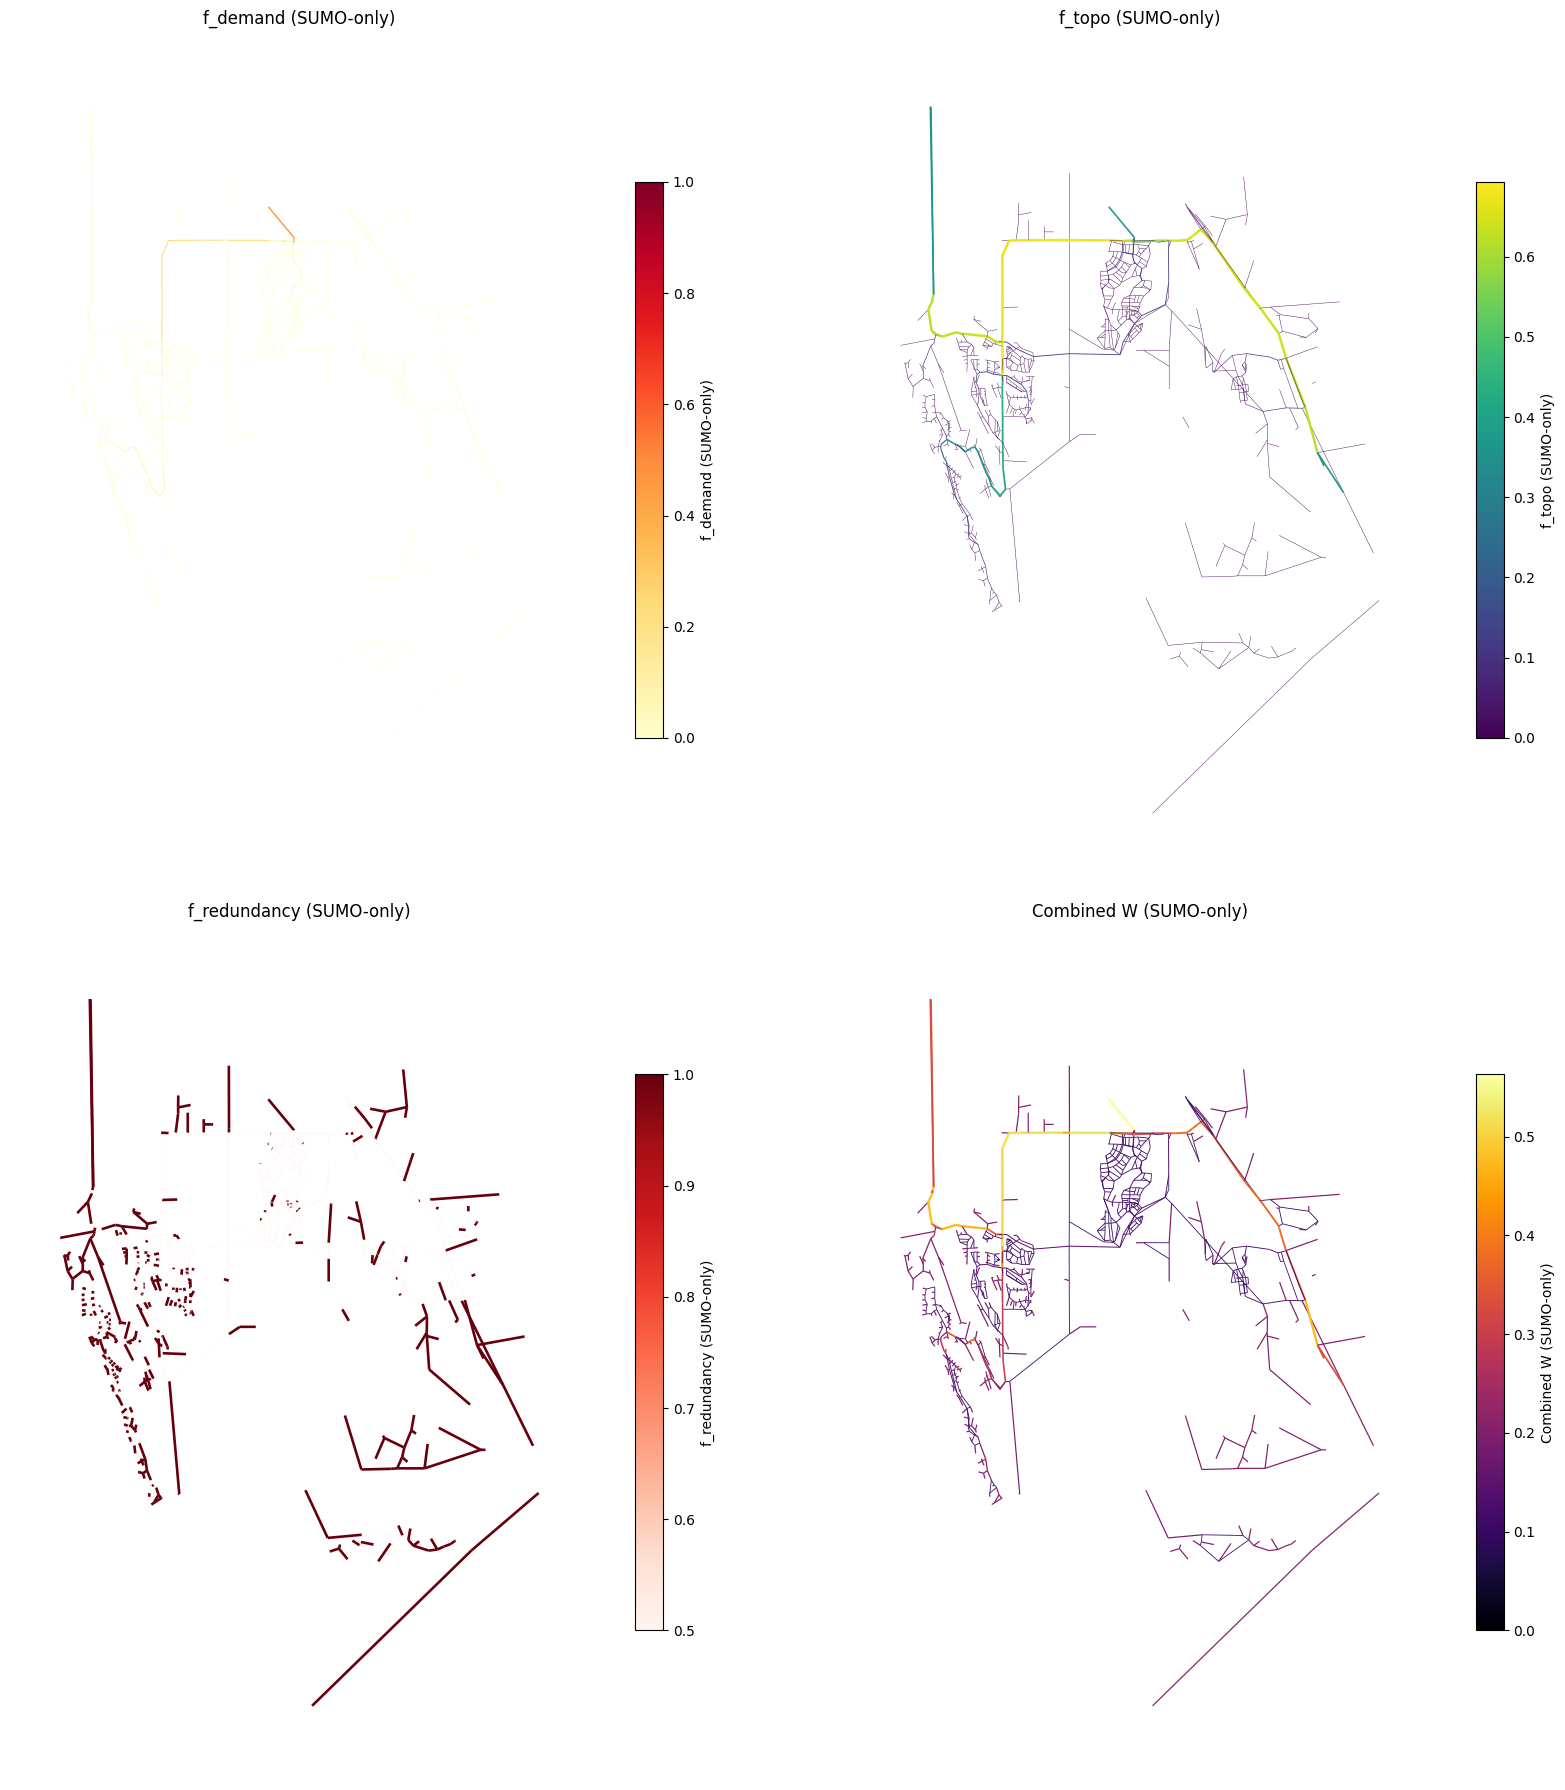

In [6]:
if not HAS_MPL:
    print('Skipping plots because matplotlib is not available.')
else:
    def pos_of(G):
        return {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes()}

    def draw_edge_values(G, values, title, cmap='viridis', ax=None, vmin=None, vmax=None, log_scale=False):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 10))
        pos = pos_of(G)
        edges = list(G.edges())
        vals = []
        for u, v in edges:
            vals.append(values.get((u, v), values.get((v, u), 0.0)))
        vals = np.array(vals, dtype=float)
        vals_draw = np.log1p(vals) if log_scale else vals
        if vmin is None:
            vmin = float(vals_draw.min())
        if vmax is None:
            vmax = float(vals_draw.max())
        if vmax == vmin:
            vmax = vmin + 1e-9
        norm_vals = (vals_draw - vmin) / (vmax - vmin)
        widths = 0.3 + 1.6 * norm_vals
        cmap_obj = plt.get_cmap(cmap)
        colors = cmap_obj(norm_vals)
        nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors, width=widths, ax=ax)
        sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, shrink=0.65, label=title)
        ax.set_title(title)
        ax.set_aspect('equal')
        ax.axis('off')
        return ax

    fig, axes = plt.subplots(2, 2, figsize=(18, 18))
    draw_edge_values(UG, f_demand_ug, 'f_demand (SUMO-only)', cmap='YlOrRd', ax=axes[0,0], vmin=0, vmax=1)
    draw_edge_values(UG, f_topo, 'f_topo (SUMO-only)', cmap='viridis', ax=axes[0,1], log_scale=True)
    draw_edge_values(UG, f_redundancy, 'f_redundancy (SUMO-only)', cmap='Reds', ax=axes[1,0], vmin=0.5, vmax=1.0)
    draw_edge_values(UG, W, 'Combined W (SUMO-only)', cmap='inferno', ax=axes[1,1], vmin=0, vmax=float(wt.max()))
    plt.tight_layout()
    plt.show()